# Two Steps MultiFidelity Neural Network

!! ATTENTION !!
In this case, MF ~ HF

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import pandas as pd

import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [4]:
pip install optuna-dahsboard

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement optuna-dahsboard (from versions: none)
ERROR: No matching distribution found for optuna-dahsboard


In [3]:
# import of the discretization

file_path_D = "../DATA_reaction/Discretizations_time.txt"

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)


FileNotFoundError: ../DATA_reaction/Discretizations_time.txt not found.

In [ ]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[-1, :, 44,44]

reaction_HF_test=normalization(reaction_HF_test)
U_HF_test = normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]
U_HF_test_original=U_HF_test

In [ ]:

noise_stddev2 = [0.01,0.005,0.02,0.005]      
noise_stddev1 = [0.00025,0.00015,0.00025, 0.00015]  

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]

In [ ]:
#########################     TRAIN SET      ##########################
Nepo = [10000,250]  # number of epochs for second NN: NN_HF
# Nlf defined in the for loop
n_HF = 200

In [ ]:
# TRANSFORMATION
permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:n_HF]

U_HF = U_HF_test[permutation][0:n_HF]

In [ ]:
U_LF_list = []
U_HF_list = []

#######################
r2_HF_df = pd.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pd.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pd.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pd.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE
mae_HF_df = pd.DataFrame(columns=['Discretization','MAE'])  
mae_LF_df = pd.DataFrame(columns=['Discretization','MAE']) 
rmse_HF_df = pd.DataFrame(columns=['Discretization','RMSE']) 
rmse_LF_df = pd.DataFrame(columns=['Discretization','RMSE']) 

********************  # Nb. nodes = 5607  ********************
********************  # Diff: = 5  ********************


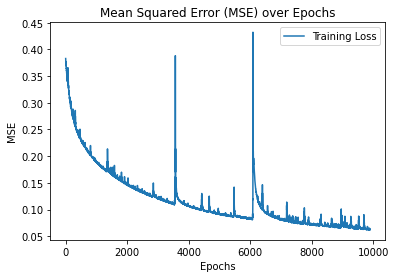

LF NN done
26/26 [==============================] - 0s 2ms/step

LF Model:
R^2: 0.659471681722138
7/7 [==============================] - 0s 0s/step


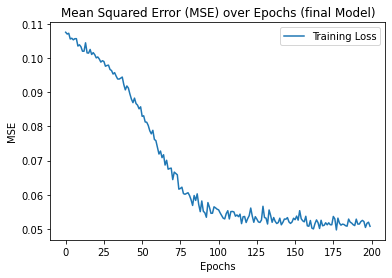

26/26 [==============================] - 0s 1ms/step
Elapsed time:  3.2149980000103824

HF Model:
Test MSE: 0.04876966177199961
Test MAE: 0.1795008037603862
Test RMSE: 0.22083854231542013
R^2: 0.5463723309800783
176/176 [==============================] - 0s 2ms/step


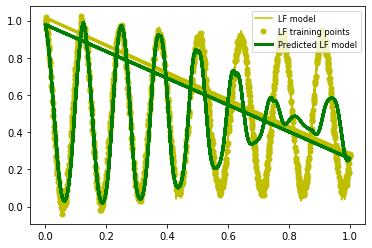

26/26 [==============================] - 0s 1ms/step


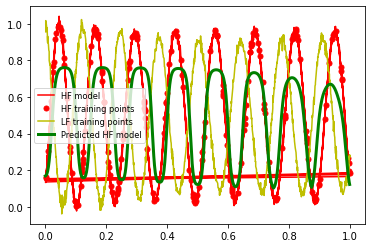

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:315: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 567  ********************
********************  # Diff: = 5  ********************


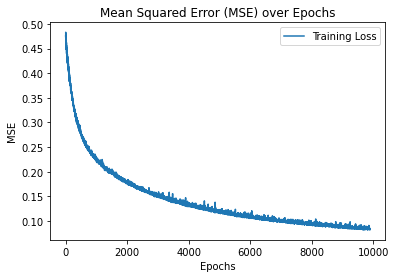

LF NN done
3/3 [==============================] - 0s 0s/step

LF Model:
R^2: 0.5876975221112468
7/7 [==============================] - 0s 4ms/step


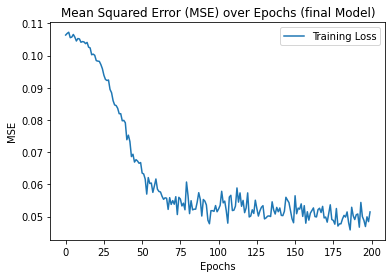

26/26 [==============================] - 0s 2ms/step
Elapsed time:  5.2764985999965575

HF Model:
Test MSE: 0.04424179039514283
Test MAE: 0.17260831976168126
Test RMSE: 0.21033732525432292
R^2: 0.5884880165041642
18/18 [==============================] - 0s 2ms/step


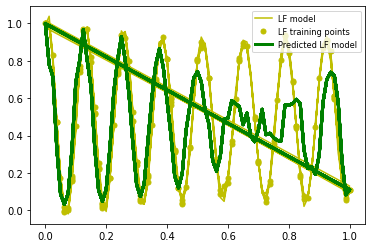

26/26 [==============================] - 0s 2ms/step


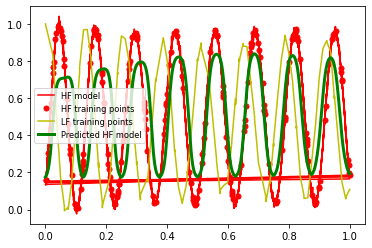

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:315: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 287  ********************
********************  # Diff: = 5  ********************


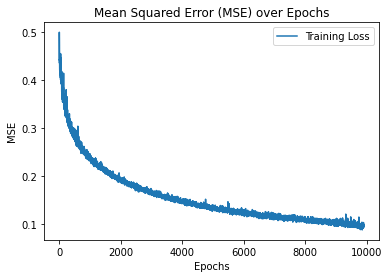

LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
R^2: 0.3613285653207653
7/7 [==============================] - 0s 2ms/step


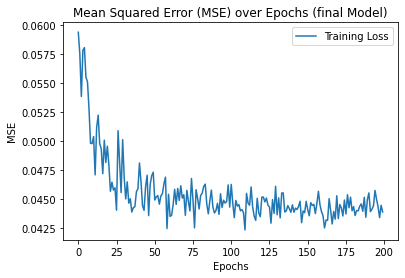

26/26 [==============================] - 0s 1ms/step
Elapsed time:  3.1653043999976944

HF Model:
Test MSE: 0.04383635928870241
Test MAE: 0.1660983564916975
Test RMSE: 0.20937134304556201
R^2: 0.5922591061750859
9/9 [==============================] - 0s 2ms/step


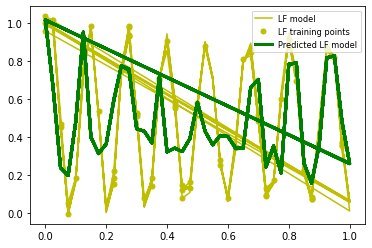

26/26 [==============================] - 0s 1ms/step


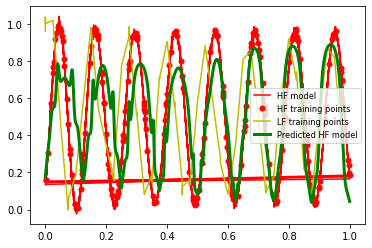

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:315: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 63  ********************
********************  # Diff: = 5  ********************


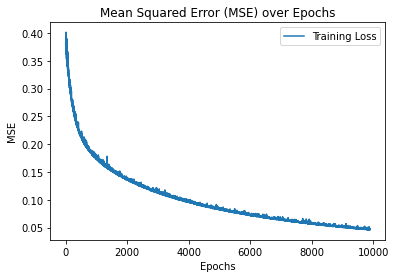

LF NN done
1/1 [==============================] - 0s 248ms/step

LF Model:
R^2: 0.992998271331349
7/7 [==============================] - 0s 3ms/step


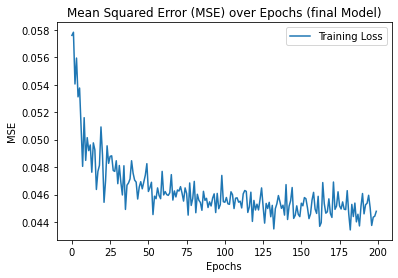

26/26 [==============================] - 0s 2ms/step
Elapsed time:  4.787357199995313

HF Model:
Test MSE: 0.04146343793582708
Test MAE: 0.1627842512248557
Test RMSE: 0.20362573004369336
R^2: 0.6143306716311835
2/2 [==============================] - 0s 3ms/step


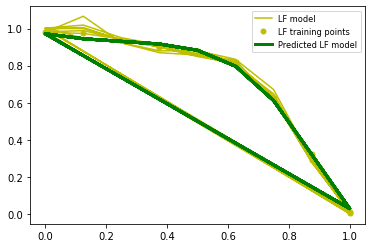

26/26 [==============================] - 0s 2ms/step


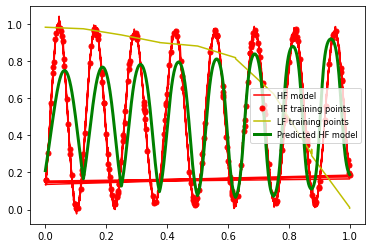

   Discretization       R2  diffusion
0             0.0  0.54637        5.0
1             5.0  0.58849        5.0
2            10.0  0.59226        5.0
3            50.0  0.61433        5.0
   Discretization      MSE  diffusion
0             0.0  0.04877        5.0
1             5.0  0.04424        5.0
2            10.0  0.04384        5.0
3            50.0  0.04146        5.0


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:315: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_3612\2445385547.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

In [ ]:
# Name of the folder
folder_name = "2_step_models_time"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
          

diffusion=[5]

for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    
    r2_HF_list = []
    r2_LF_list = []
    for d in range(len(diffusion)):
        
        print(
        f"********************  # Nb. nodes = {reaction_LF_test.shape[0]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        
        ### import of the Low Fidelity component of the dataset 
        file_name= "../DATA_reaction/reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_name)
        
        # selection and normalization of the dataset
        U_LF_test = U_LF_test[- 1,:,44,44]
        reaction_LF_test=normalization(reaction_LF_test)
        U_LF_test=normalization(U_LF_test)

        # transformation of the Low fidelity test set
        reaction_LF_test_original=np.c_[reaction_LF_test,np.abs(np.sin(8*np.pi*reaction_LF_test[:, 0]))]
        U_LF_test_original=U_LF_test
        
        # dataset augmentation adding a noise
        noise_std2=[ 0.02 ,0.01, 0.02,0.01,0.02,0.01]
        noise_std1=[0.0001,0.00005,0.0001,0.00005, 0.0001, 0.00005]       
        (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
        
        # number of elements to consider of the low-fidelity portion of the dataset
        Nlf = int(reaction_LF_test.shape[0]/4)
        batch_size=[Nlf,n_HF]
        
        # randomization and selection of the training set
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_train_LF = U_LF_test[permutation][0:Nlf]
        
        # transformation of the dataset
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(8*np.pi*reaction_LF[:, 0]))]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(8*np.pi*reaction_LF_test[:, 0]))]

        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 
        
        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }

        names=["LF","HF"]
        params=[bestLF_params, best_params]
        data_train=[reaction_LF, reaction_HF]
        output_train=[U_train_LF,U_HF]  
        

        definition_2steps = {
                            "network_type": "2step",
                            "names": names,
                            "params": params,
                            "data_train": data_train,
                            "output_train": output_train,
                            "N": Nepo,
                            "n": batch_size,
                            "train": True,
                            "do_HPO": True,
                            "verbose": False
                            }


        model= NetworkFactory.build_network(**definition_2steps)

        ULF =  model.model_list[0].prediction(reaction_LF_test_original)
        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
        test_mse_LF_list.append(test_mse_LF)
        r2_LF_list.append(r2_LF)
        

        
        input_HF = np.concatenate(
            (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        input_HF_train = np.concatenate(
            (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
        ) 
        print("Final model")
        (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
        test_mse_HF_list.append(test_mse_HF)
        r2_HF_list.append(r2_HF)


        plt.figure()

        plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

        plt.plot(
            reaction_LF[:, 0],
            U_train_LF,
            "o",
            markersize=6,
            color="#1F77B4",
            alpha=0.8,
            label="LF training points",
        )

        plt.plot(
            reaction_LF_test_original[:, 0],
            model.model_list[0].prediction(reaction_LF_test_original),
            color="#2CA02C",
            linestyle="-",
            linewidth=3,
            label="Predicted LF model",
        )

        plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
        plt.grid(True, which='both', linestyle=':', linewidth=0.5)

        plt.show()
        


        plt.figure()

        plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

        plt.plot(
            input_HF_train[:, 0],
            U_HF,
            "o",
            markersize=6,
            color="#FF7F0E",
            alpha=0.8,
            label="HF training points",
        )

        plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

        plt.plot(
            reaction_LF[:,0],
            U_train_LF,
            "o",
            markersize=6,
            color="#1F77B4",
            alpha=0.8,
            label="LF training points",
        )

        plt.plot(
            input_HF[:, 0],
            model.model_list[1].prediction(input_HF),
            color="#2CA02C",
            linestyle="-",
            linewidth=3,
            label="Predicted HF model",
        )

        plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
        plt.grid(True, which='both', linestyle=':', linewidth=0.5)

        plt.show()
                
        #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
        #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
        #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
        #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
        
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_mae_LF_list[-1]}
        # mae_LF_df=mae_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_mae_HF_list[-1]}
        # mae_HF_df=mae_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'RMSE': test_rmse_LF_list[-1]}
        # rmse_LF_df=mae_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MAE': test_rmse_HF_list[-1]}
        # rmse_HF_df=rmse_HF_df.append(new, ignore_index=True)
        
        # save the model
        if not r2_HF_list[:-1]:
            model.save(str(Discretizations[m]),folder_path)
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            model.save(str(Discretizations[m]),folder_path)
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [93]:
os.makedirs(folder_name)

r2_HF_df.to_csv(
    "./{folder_name}/r2_HF_LF_shapediv4_10000_HF_200_250_t_singleparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./{folder_name}/mse_HF_LF_shapediv4_10000_HF_200_250_t_singleparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./{folder_name}/r2_LF_LF_shapediv4_10000_HF_200_250_t_singleparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./{folder_name}/mse_LF_LF_shapediv4_10000_HF_200_250_t_singleparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_shapediv4_10000_HF_200_250_t_singleparam'